# Finetune ESM-2 using LoRA.

## Abstract

This notebook attempts to fine-tune ESM-2 using LoRA to be organism-specific, adapting the model on the *A. baylyi* proteome, and expands on the *Species Bias* notebook to explore if fine-tuning ESM-2 can address or magnify species-specific effects. Given the non-normal distribution of log-likelihood differences, long negative tails, we identified the Sign test, fraction improved and bootstrapped median. The largest improvement in log-likelihood was the *A. baylyi* sequences, affirming the fine-tuning procedure was successful, while the out-of-distribution sequences of *E. coli* and UniRef50 were smaller in fraction improved and bootstrapped median.

## Background


ESM-2 is a pretrained protein language model with the largest version containing 15 billion parameters. Training these models is computationally expensive, requiring 512 V100 GPUs across 60 days for the 15 billion parameter model ([Lin et al. 2023](https://www.science.org/doi/10.1126/science.ade2574)).

Downstream applications typically use ESM-2 embeddings or fine-tune ESM-2 for the specific tasks predicting protein fitness, detecting protein disordered regions, and modeling mutation effects. Fine-tuning protein language models with large number of parameters is computationally and memory-intensive. The natural language processing field has defined efficient ways to fine-tune models on the order of hundreds of billion parameters while reducing computational and memory cost. LoRA (Low-Rank Adaptation) is an efficient fine-tuning method to reduce the number of trainable parameters while retaining similar or better performance than traditional fine-tuning methods. Specifically, LoRA introduces a small set of new trainable low-rank matrices while the original model parameters are frozen ([Hu et al. 2021](https://arxiv.org/abs/2106.09685)).

**Project Question**: Does fine-tuning ESM-2 on the *A. baylyi* proteome increase the protein likelihood under the model?


## Hypothesis


Fine-tuning ESM-2 on the *A. baylyi* proteome  will increase the likelihoods of the *A. baylyi* proteins relative to the baseline ESM-2 model.


## Project Goal


1. Compute the baseline negative log-likelihoods using the pretrained ESM-2 model.
2. Fine-tune ESM-2: full parameter fine-tuning and LoRA.
3. Compare baseline and LoRA fine-tuned models across *A. baylyi*, *E. coli*, and UniRef50 sequence datasets.

<img src="https://lucid.app/publicSegments/view/f595fe86-5d04-4ff3-9eea-496ada188c4b/image.png" width="500">

# 00: Install and import relevant packages.

- fair-esm: load ESM model parameters and compute likelihoods.

- [homolog-search-tools](https://github.com/chrisnguyen11/homolog-search-tools): utility functions to fetch sequences from UniProt using the REST API and process sequence data.

- pytorch: deep learning framework.

- transformers: Huggingface library to load, train, finetune, and predict with pre-trained transformer-based models.

- datasets: Huggingface library to load and process datasets for machine learning models.

- peft: Huggingface library for parameter-efficient fine-tuning python including LoRA.

- scipy: statistical computations.


In [ ]:
!pip install -q fair-esm
!pip install -q git+https://github.com/chrisnguyen11/homolog-search-tools.git

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.1/93.1 kB 12.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [ ]:
import re
from tqdm.notebook import tqdm

import math
import numpy as np
import pandas as pd

from scipy.stats import normaltest, levene, binomtest, bootstrap
from statsmodels.stats.proportion import proportion_confint

import matplotlib.pyplot as plt
import seaborn as sns

import torch
from torch.nn.functional import softmax

from transformers import (
    AutoTokenizer, AutoModelForMaskedLM, DataCollatorForLanguageModeling,
    Trainer, TrainingArguments
)
from datasets import Dataset
from peft import get_peft_model, LoraConfig, TaskType

import esm
from esm import FastaBatchedDataset

from homolog_search_tools.utils import read_fasta, write_fasta
from homolog_search_tools.search import UniProtRequest, uniprotrecords_to_dataframe

# 01: Prepare sequences.

Filter *A. baylyi* and *E. coli* sequences for non-natural residues for reliable ESM-2 computations.

Download UniRef50 sequences from UniProt.

In [ ]:
def is_natural_sequence(sequence: str) -> bool:
    """Return True if sequence contains only the 20 natural amino acids."""
    natural_aas = set("LAGVSERTIDPKQNFYMHWC")
    return all(residue in natural_aas for residue in sequence)

def fasta_to_dataframe(fasta_path, natural_residues="LAGVSERTIDPKQNFYMHWC"):
  """
  Convert fasta files into pandas dataframe
  while removing records containing skip_seq_char.

  Parameters
  ----------
  fasta_path: str
    Path to fasta file.
  skip_seq_char: str
  """
  headers, seqs = read_fasta(fasta_path)
  df = pd.DataFrame({"Header": headers, "Sequence": seqs})
  skip_df = df[~df["Sequence"].apply(is_natural_sequence)]
  skip_df = pd.concat([skip_df, df[df["Sequence"].apply(lambda x: len(x) < 1)]])
  print(f"Read {len(headers)} and removed {len(skip_df)} sequences")
  return df.drop(skip_df.index)

In [ ]:
seqs_83333_df = fasta_to_dataframe("proteome-taxid_83333.fasta")
seqs_62977_df = fasta_to_dataframe("proteome-taxid_62977.fasta")

Read 4318 and removed 6 sequences
Read 3310 and removed 0 sequences


In [ ]:
write_fasta(seqs_83333_df, "pruned-proteome-taxid_83333.fasta")
write_fasta(seqs_62977_df, "pruned-proteome-taxid_62977.fasta")

In [ ]:
# parse list of vaild uniref50 accessions
pattern = "[OPQ][0-9][A-Z0-9]{3}[0-9]|[A-NR-Z][0-9]([A-Z][A-Z0-9]{2}[0-9]){1,2}"

uniref50_accessions = []
with open("uniref201803_ur50_valid_headers.txt","r") as f:
  for line in f:
    try:
      uniref50_accessions.append(re.search(pattern,line)[0])
    except:
      pass

# fetch UniProt data from accessions
uniprot_api = UniProtRequest("cnguyen11@luc.edu")
uniref50_records = uniprot_api.fetch_records(uniref50_accessions[:10_000])

uniref50_df = uniprotrecords_to_dataframe(uniref50_records)

# write uniref50 sample to fasta
write_fasta(uniref50_df, "uniref50_sample.fasta",
            header_col="primaryAccession", sequence_col="sequence"
            )

# 02: Compute baseline negative log-likelihood under ESM-2.

Load the ESM-2 pretrained model and compute the baseline negative log-likelihoods.

- Evaluate each sequence with a single pass by summing the negative log conditional probabilities of every amino acid.



In [ ]:
model, alphabet =  esm.pretrained.esm2_t6_8M_UR50D()
batch_converter = alphabet.get_batch_converter()

Downloading: "https://dl.fbaipublicfiles.com/fair-esm/models/esm2_t6_8M_UR50D.pt" to /root/.cache/torch/hub/checkpoints/esm2_t6_8M_UR50D.pt
Downloading: "https://dl.fbaipublicfiles.com/fair-esm/regression/esm2_t6_8M_UR50D-contact-regression.pt" to /root/.cache/torch/hub/checkpoints/esm2_t6_8M_UR50D-contact-regression.pt


In [ ]:
def extract(
    model, alphabet, sequences, repr_layers=[], agg="mean",
    truncation_seq_length=1022,
    toks_per_batch=4096, ALPHABET = "LAGVSERTIDPKQNFWYMHC",
    device="cuda"
    ):
  """
  Extracts and processes sequence representations using ESM-2. Code modified
  from the [extract.py](https://github.com/facebookresearch/esm/blob/main/scripts/extract.py)
  in the ESM repo.

  Parameters
  ----------
  model: str
    ESM model object.
  alphabet: str
    ESM alphabet object.
  sequences: str
    Path to fasta file.
  repr_layers: list[int]
    List of layers to extract representations from.
  """
  # Load model parameters and sequence data
  model.to(device)
  model.eval()
  dataset = esm.FastaBatchedDataset.from_file(sequences)
  batches = dataset.get_batch_indices(toks_per_batch, extra_toks_per_seq=1)
  data_loader = torch.utils.data.DataLoader(
    dataset, collate_fn=alphabet.get_batch_converter(truncation_seq_length),
    batch_sampler=batches
  )
  tok_to_idx = alphabet.tok_to_idx

  # Inference
  with torch.no_grad():
    output = []
    for batch_idx, (labels, strs, toks) in tqdm(enumerate(data_loader)):
      toks = toks.to(device=device) # Move toks to the specified device
      batch_output = model(toks, repr_layers=repr_layers)
      batch_logits = batch_output["logits"].to(device=device)

      for i, label in enumerate(labels):
        # Compute LL
        seq_length = truncation_seq_length if len(strs[i]) > truncation_seq_length else len(strs[i])
        batch_probs = torch.nn.functional.softmax(batch_logits[i, 1:seq_length+1], dim=1)
        batch_log_probs = torch.log(batch_probs)
        residue_log_probs = [batch_log_probs[j, tok_to_idx[aa]].item() for j, aa in enumerate(strs[i]) if j < seq_length]

        log_prob = (1/seq_length) * np.sum(residue_log_probs)

        perplexity = np.exp(-log_prob)

        # Save sequence data
        _output = {
            "Sequence":strs[i], "perplexity":perplexity, "log_likelihood":log_prob,
            "batch_probs": batch_probs
            }
        if len(repr_layers) > 0:
          batch_representations = {
            layer: rep.to(device="cpu") for layer, rep in batch_output["representations"].items()
          }
          _output["embedding"] = batch_representations[repr_layers[0]][i, 1:seq_length+1].numpy()
          _output["mean_embedding"] = batch_representations[repr_layers[0]][i, 1:seq_length+1].mean(0).numpy()
        output.append(_output)
  return output

In [ ]:
esm_83333 = extract(model, alphabet, "pruned-proteome-taxid_83333.fasta", repr_layers=[])
esm_62977 = extract(model, alphabet, "pruned-proteome-taxid_62977.fasta", repr_layers=[])
esm_uniref50 = extract(model, alphabet, "uniref50_sample.fasta", repr_layers=[])

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

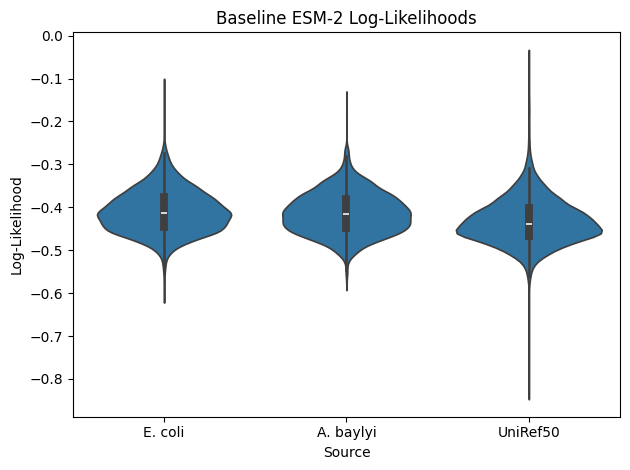

In [ ]:
esm_83333_df = pd.DataFrame(esm_83333).drop_duplicates(subset="Sequence")
seqs_83333_df["Short_Header"] = seqs_83333_df["Header"].apply(lambda x: x.split("|")[1][17:28]) # E. coli unique header

esm_83333_df = esm_83333_df.merge(seqs_83333_df, on="Sequence")
esm_83333_df = esm_83333_df[["Short_Header", "Sequence", "perplexity", "log_likelihood"]]
esm_83333_df = esm_83333_df.rename(columns={"Short_Header":"Header", "sequence": "Sequence"})
esm_83333_df["Source"] = "E. coli"

####
esm_62977_df = pd.DataFrame(esm_62977).drop_duplicates(subset="Sequence")
seqs_62977_df["Short_Header"] = seqs_62977_df["Header"].apply(lambda x: x.split("|")[1][:10]) # A. baylyi unique header

esm_62977_df = esm_62977_df.merge(seqs_62977_df, on="Sequence")
esm_62977_df = esm_62977_df[["Short_Header", "Sequence", "perplexity", "log_likelihood"]]
esm_62977_df = esm_62977_df.rename(columns={"Short_Header":"Header", "sequence": "Sequence"})
esm_62977_df["Source"] = "A. baylyi"

####
esm_uniref50_df = pd.DataFrame(esm_uniref50).drop_duplicates(subset="Sequence")
esm_uniref50_df = esm_uniref50_df.merge(uniref50_df, right_on="sequence", left_on="Sequence")
esm_uniref50_df["Source"] = "UniRef50"
esm_uniref50_df = esm_uniref50_df[["primaryAccession", "sequence", "perplexity", "log_likelihood", "Source"]]
esm_uniref50_df = esm_uniref50_df.rename(columns={"primaryAccession":"Header", "sequence": "Sequence"})
#####
baseline_esm_df = pd.concat([esm_83333_df, esm_62977_df, esm_uniref50_df])
sns.violinplot(baseline_esm_df, x="Source", y="log_likelihood")

plt.xlabel("Source")
plt.ylabel("Log-Likelihood")
plt.title("Baseline ESM-2 Log-Likelihoods")
plt.tight_layout()

# 03: Finetune ESM-2 directly.

Load the ESM-2 pretrained model using the Huggingface transformer library and fine-tune ESM-2 directly.


In [ ]:
tokenizer = AutoTokenizer.from_pretrained("facebook/esm2_t6_8M_UR50D")
model = AutoModelForMaskedLM.from_pretrained("facebook/esm2_t6_8M_UR50D")

data_collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer, mlm_probability=0.15
    )

model.num_parameters()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/775 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/95.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/93.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/31.4M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/112 [00:00<?, ?it/s]

EsmForMaskedLM LOAD REPORT from: facebook/esm2_t6_8M_UR50D
Key                         | Status     |  | 
----------------------------+------------+--+-
esm.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


7512474

In [ ]:
tokenized_dataset = tokenizer(seqs_62977_df["Sequence"].to_list())
full_dataset = Dataset.from_dict(tokenized_dataset)

split_datasets = full_dataset.train_test_split(test_size=0.2, seed=42)

# Access the training and testing sets
train_dataset = split_datasets['train']
test_dataset = split_datasets['test']

In [ ]:
train_args = TrainingArguments(
    output_dir="finetune-model-files",
    eval_strategy = "epoch",
    save_strategy = "epoch",
    learning_rate=5e-4,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=20,
    weight_decay=0.01,
    load_best_model_at_end=True,
    logging_steps=1,
)
trainer = Trainer(
    model,
    train_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    processing_class=tokenizer,
    data_collator=data_collator,
)

In [ ]:
trainer.train()

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 2}.


Epoch,Training Loss,Validation Loss
1,2.510569,2.520306
2,2.585408,2.502865
3,2.380032,2.503292
4,2.483898,2.507210
5,2.349196,2.487081
6,2.445900,2.494937
7,2.358706,2.478245
8,2.350338,2.483871
9,2.567516,2.485613
10,2.318202,2.473404


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['esm.encoder.layer.0.attention.LayerNorm.weight', 'esm.encoder.layer.0.attention.LayerNorm.bias', 'esm.encoder.layer.0.LayerNorm.weight', 'esm.encoder.layer.0.LayerNorm.bias', 'esm.encoder.layer.1.attention.LayerNorm.weight', 'esm.encoder.layer.1.attention.LayerNorm.bias', 'esm.encoder.layer.1.LayerNorm.weight', 'esm.encoder.layer.1.LayerNorm.bias', 'esm.encoder.layer.2.attention.LayerNorm.weight', 'esm.encoder.layer.2.attention.LayerNorm.bias', 'esm.encoder.layer.2.LayerNorm.weight', 'esm.encoder.layer.2.LayerNorm.bias', 'esm.encoder.layer.3.attention.LayerNorm.weight', 'esm.encoder.layer.3.attention.LayerNorm.bias', 'esm.encoder.layer.3.LayerNorm.weight', 'esm.encoder.layer.3.LayerNorm.bias', 'esm.encoder.layer.4.attention.LayerNorm.weight', 'esm.encoder.layer.4.attention.LayerNorm.bias', 'esm.encoder.layer.4.LayerNorm.weight', 'esm.encoder.layer.4.LayerNorm.bias', 'esm.encoder.layer.5.attention.LayerNorm.weight', 'esm.encoder.

TrainOutput(global_step=6620, training_loss=2.348626367599222, metrics={'train_runtime': 1306.661, 'train_samples_per_second': 40.531, 'train_steps_per_second': 5.066, 'total_flos': 1591683854084352.0, 'train_loss': 2.348626367599222, 'epoch': 20.0})

<Axes: xlabel='epoch_floor', ylabel='loss'>

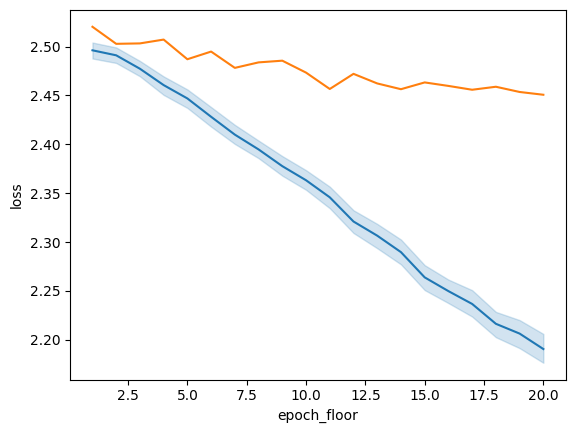

In [ ]:
full_finetune_loss_df = pd.DataFrame(trainer.state.log_history)
full_finetune_loss_df["epoch_floor"] = full_finetune_loss_df["epoch"].apply(math.ceil)

sns.lineplot(
    full_finetune_loss_df, x="epoch_floor", y="loss"
)
sns.lineplot(
    full_finetune_loss_df, x="epoch_floor", y="eval_loss"
)

Across 20 epochs, the training loss (in blue) decreases steadily and more than the validation loss (in orange). This divergence between training and validation loss suggests that the  regimen is overfitting on the training data.

Try LORA, an alternative training regimen with regularization to reduce overfitting.

# 04: Fine-tune ESM-2 with LoRA.

Load the ESM-2 pretrained model using the transformer API and define the training arguments with the PEFT library.


In [ ]:
tokenizer = AutoTokenizer.from_pretrained("facebook/esm2_t6_8M_UR50D")
model = AutoModelForMaskedLM.from_pretrained("facebook/esm2_t6_8M_UR50D")

data_collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer, mlm_probability=0.15
    )

Loading weights:   0%|          | 0/112 [00:00<?, ?it/s]

EsmForMaskedLM LOAD REPORT from: facebook/esm2_t6_8M_UR50D
Key                         | Status     |  | 
----------------------------+------------+--+-
esm.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
tokenized_dataset = tokenizer(seqs_62977_df["Sequence"].to_list())
full_dataset = Dataset.from_dict(tokenized_dataset)

split_datasets = full_dataset.train_test_split(test_size=0.2, seed=42)

# Access the training and testing sets
train_dataset = split_datasets['train']
test_dataset = split_datasets['test']

### Selecting LORA hyperparameters


- **task_type**: Fine-tuning task, typically *CAUSAL_LM*, *SEQ_2_SEQ_LM*.  
- **r**: LORA decomposes the weight matrix into two smaller matrices determined by **r**. A larger **r** defines larger matrices with more trainable parameters.
- **target_modules**: Defines which modules are being training, additional modules demands more memory. Common modules include *query*, *key*, *value*, and *output*, name convention depends on the specific model.
- **lora_alpha**: Scales the learned weights relative to the pretrained weights. A larger **lora_alpha** magnafies the learned weights while a smaller value minimizes the effect of the learned weights.
- **lora_dropout**: Random dropout as a means to control overfitting.

Check [Huggingface PEFT](https://huggingface.co/docs/peft/v0.11.0/task_guides/lora_based_methods) for more details

In [ ]:
train_args = TrainingArguments(
    output_dir="finetune-model-files",
    eval_strategy = "epoch",
    save_strategy = "epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=40,
    weight_decay=0.01,
    load_best_model_at_end=True,
    logging_steps=1,
    gradient_accumulation_steps=2,
    lr_scheduler_type="cosine",
    warmup_steps=500,
    max_grad_norm=1.0,
)

peft_config = LoraConfig(
    bias="none", # Modified bias
    target_modules=["query","value"],
    inference_mode=False,
    r=32, lora_alpha=64, lora_dropout=0.05
  )

peft_model = get_peft_model(model, peft_config)
peft_model.print_trainable_parameters()

trainable params: 245,760 || all params: 7,758,234 || trainable%: 3.1677


In [ ]:
peft_trainer = Trainer(
    peft_model,
    train_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    processing_class=tokenizer,
    data_collator=data_collator,
)

In [ ]:
peft_trainer.train()

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 2}.


Epoch,Training Loss,Validation Loss
1,2.330266,2.339505
2,2.461867,2.332629
3,2.331840,2.326608
4,2.311759,2.319886
5,2.292330,2.319903
6,2.088227,2.325432
7,2.386804,2.317473
8,2.312274,2.309845
9,2.325288,2.311233
10,2.244078,2.311013


TrainOutput(global_step=3320, training_loss=2.305947987071003, metrics={'train_runtime': 3157.2017, 'train_samples_per_second': 33.549, 'train_steps_per_second': 1.052, 'total_flos': 3975302026257408.0, 'train_loss': 2.305947987071003, 'epoch': 40.0})

In [ ]:
df = pd.DataFrame(peft_trainer.state.log_history)
df = df[df["epoch"].apply(lambda x: x.is_integer())]
df_train = df[~df["loss"].isna()][["epoch","loss"]]
df_eval = df[df["loss"].isna()][["epoch","eval_loss"]]
df_train.merge(df_eval, on="epoch").dropna()

,epoch,loss,eval_loss
0,1.0,2.330266,2.339505
1,2.0,2.461867,2.332629
2,3.0,2.331840,2.326608
3,4.0,2.311759,2.319886
4,5.0,2.292330,2.319903
5,6.0,2.088227,2.325432
6,7.0,2.386804,2.317473
7,8.0,2.312274,2.309845
8,9.0,2.325288,2.311233
9,10.0,2.244078,2.311013


## LoRA Finetune Training.

<Axes: xlabel='epoch', ylabel='loss'>

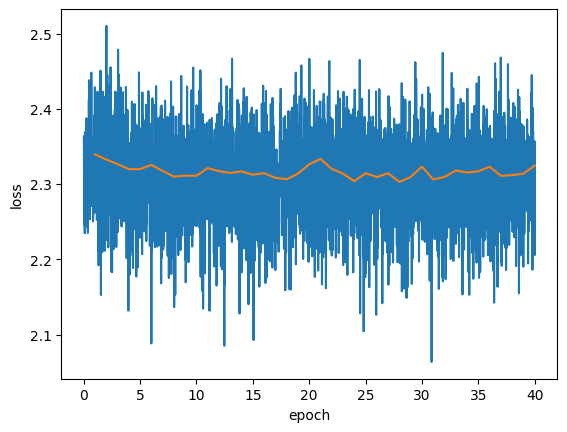

In [ ]:
peft_finetune_loss_df = pd.DataFrame(peft_trainer.state.log_history)
peft_finetune_loss_df["epoch_floor"] = peft_finetune_loss_df["epoch"].apply(math.ceil)

sns.lineplot(
    peft_finetune_loss_df, x="epoch", y="loss"
)
sns.lineplot(
    peft_finetune_loss_df, x="epoch", y="eval_loss"
)

Across the 40 epochs, finetuning ESM-2 with LoRA on the *A. baylyi* proteome is noisy but is stable. The training loss hovers around 2.32 with fluctuations likely due to the batch to batch differences. Intially, the validation loss decreases, then slowly increases again in the later epochs, with promising checkpoints at the 18th, 24th, and 28th epochs.

# 05: Compare baseline and finetuned models.

Compare the log-likelihoods under the baseline and finetuned ESM-2 protein language models.


In [ ]:
finetuned_esm_83333 = extract(peft_model, alphabet, "pruned-proteome-taxid_83333.fasta", repr_layers=[])
finetuned_esm_62977 = extract(peft_model, alphabet, "pruned-proteome-taxid_62977.fasta", repr_layers=[])
finetuned_esm_uniref50 = extract(peft_model, alphabet, "uniref50_sample.fasta", repr_layers=[])

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

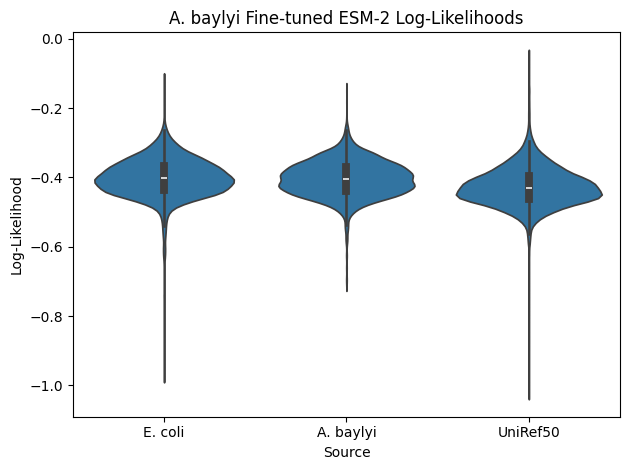

In [ ]:
finetuned_esm_83333_df = pd.DataFrame(finetuned_esm_83333).drop_duplicates(subset="Sequence")
seqs_83333_df["Short_Header"] = seqs_83333_df["Header"].apply(lambda x: x.split("|")[1][17:28])

finetuned_esm_83333_df = finetuned_esm_83333_df.merge(seqs_83333_df, on="Sequence")
finetuned_esm_83333_df = finetuned_esm_83333_df[["Short_Header", "Sequence", "perplexity", "log_likelihood"]]
finetuned_esm_83333_df = finetuned_esm_83333_df.rename(columns={"Short_Header":"Header", "sequence": "Sequence"})
finetuned_esm_83333_df["Source"] = "E. coli"

####
finetuned_esm_62977_df = pd.DataFrame(finetuned_esm_62977).drop_duplicates(subset="Sequence")
seqs_62977_df["Short_Header"] = seqs_62977_df["Header"].apply(lambda x: x.split("|")[1][:10])

finetuned_esm_62977_df = finetuned_esm_62977_df.merge(seqs_62977_df, on="Sequence")
finetuned_esm_62977_df = finetuned_esm_62977_df[["Short_Header", "Sequence", "perplexity", "log_likelihood"]]
finetuned_esm_62977_df = finetuned_esm_62977_df.rename(columns={"Short_Header":"Header", "sequence": "Sequence"})
finetuned_esm_62977_df["Source"] = "A. baylyi"

####
finetuned_esm_uniref50_df = pd.DataFrame(finetuned_esm_uniref50).drop_duplicates(subset="Sequence")
finetuned_esm_uniref50_df = finetuned_esm_uniref50_df.merge(uniref50_df, right_on="sequence", left_on="Sequence")
finetuned_esm_uniref50_df["Source"] = "UniRef50"
finetuned_esm_uniref50_df = finetuned_esm_uniref50_df[["primaryAccession", "sequence", "perplexity", "log_likelihood", "Source"]]
finetuned_esm_uniref50_df = finetuned_esm_uniref50_df.rename(columns={"primaryAccession":"Header", "sequence": "Sequence"})
#####
finetuned_esm_df = pd.concat([finetuned_esm_83333_df, finetuned_esm_62977_df, finetuned_esm_uniref50_df])
sns.violinplot(finetuned_esm_df, x="Source", y="log_likelihood")

plt.xlabel("Source")
plt.ylabel("Log-Likelihood")
plt.title("A. baylyi Fine-tuned ESM-2 Log-Likelihoods")
plt.tight_layout()

## Compute statistics on the log-likelihood distributions

Assess if the baseline and fine-tuned log-likelihood distributions are normally distributed and have comparable variances (homogeneity).

In [ ]:
# Summary statistics of the log-likelihood distributions
pd.DataFrame({
    ("A. baylyi", "Baseline"): {
        "Mean": esm_62977_df["log_likelihood"].mean(),
        "Median": esm_62977_df["log_likelihood"].median(),
        "Variance": esm_62977_df["log_likelihood"].var(),
        "Max": esm_62977_df["log_likelihood"].max(),
        "Min": esm_62977_df["log_likelihood"].min(),
        },
    ("A. baylyi", "Fine-tuned"): {
        "Mean": finetuned_esm_62977_df["log_likelihood"].mean(),
        "Median": finetuned_esm_62977_df["log_likelihood"].median(),
        "Variance": finetuned_esm_62977_df["log_likelihood"].var(),
        "Max": finetuned_esm_62977_df["log_likelihood"].max(),
        "Min": finetuned_esm_62977_df["log_likelihood"].min(),
      },
    ("E. coli", "Baseline"): {
        "Mean": esm_83333_df["log_likelihood"].mean(),
        "Median": esm_83333_df["log_likelihood"].median(),
        "Variance": esm_83333_df["log_likelihood"].var(),
        "Max": esm_83333_df["log_likelihood"].max(),
        "Min": esm_83333_df["log_likelihood"].min(),
        },
    ("E. coli", "Fine-tuned"): {
        "Mean": finetuned_esm_83333_df["log_likelihood"].mean(),
        "Median": finetuned_esm_83333_df["log_likelihood"].median(),
        "Variance": finetuned_esm_83333_df["log_likelihood"].var(),
        "Max": finetuned_esm_83333_df["log_likelihood"].max(),
        "Min": finetuned_esm_83333_df["log_likelihood"].min(),
      },
    ("UniRef50", "Baseline"): {
        "Mean": esm_uniref50_df["log_likelihood"].mean(),
        "Median": esm_uniref50_df["log_likelihood"].median(),
        "Variance": esm_uniref50_df["log_likelihood"].var(),
        "Max": esm_uniref50_df["log_likelihood"].max(),
        "Min": esm_uniref50_df["log_likelihood"].min(),
        },
    ("UniRef50", "Fine-tuned"): {
        "Mean": finetuned_esm_uniref50_df["log_likelihood"].mean(),
        "Median": finetuned_esm_uniref50_df["log_likelihood"].median(),
        "Variance": finetuned_esm_uniref50_df["log_likelihood"].var(),
        "Max": finetuned_esm_uniref50_df["log_likelihood"].max(),
        "Min": finetuned_esm_uniref50_df["log_likelihood"].min(),
      },
}).T

Mean    Median  Variance       Max       Min
A. baylyi Baseline   -0.413430 -0.415673  0.002337 -0.149045 -0.573742
          Fine-tuned -0.402921 -0.403365  0.002632 -0.147856 -0.707114
E. coli   Baseline   -0.409445 -0.413692  0.002477 -0.118993 -0.603526
          Fine-tuned -0.401906 -0.402853  0.003452 -0.121139 -0.969374
UniRef50  Baseline   -0.431996 -0.437838  0.002903 -0.051792 -0.828543
          Fine-tuned -0.426056 -0.430902  0.003221 -0.051225 -1.020406

Text(0, 0.5, 'Log-Likelihood')

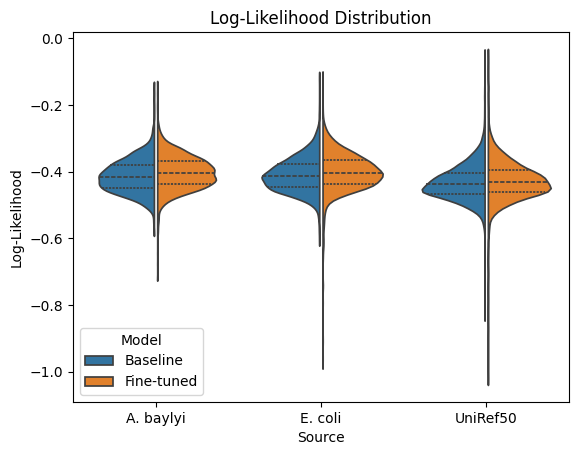

In [ ]:
# Plot the log-likelihood distributions together

loglikelihood_62977_df = pd.merge(esm_62977_df.drop_duplicates(subset="Sequence"),
         finetuned_esm_62977_df.drop_duplicates(subset="Sequence"),
         on=["Header","Sequence"], suffixes=("_baseline", "_finetuned")
)
loglikelihood_83333_df = pd.merge(esm_83333_df.drop_duplicates(subset="Sequence"),
         finetuned_esm_83333_df.drop_duplicates(subset="Sequence"),
         on=["Header","Sequence"], suffixes=("_baseline", "_finetuned")
)
loglikelihood_uniref50_df = pd.merge(esm_uniref50_df.drop_duplicates(subset="Sequence"),
         finetuned_esm_uniref50_df.drop_duplicates(subset="Sequence"),
         on=["Header","Sequence"], suffixes=("_baseline", "_finetuned")
)

joint_df = pd.concat([loglikelihood_62977_df, loglikelihood_83333_df, loglikelihood_uniref50_df])
joint_long_df = joint_df.melt(id_vars=["Header", "Sequence", "Source_baseline"], value_vars=["log_likelihood_baseline","log_likelihood_finetuned"], var_name="Model", value_name="log_likelihood")
joint_long_df["Model"] = joint_long_df["Model"].map({"log_likelihood_finetuned": "Fine-tuned", "log_likelihood_baseline": "Baseline"})
sns.violinplot(joint_long_df, x="Source_baseline", y="log_likelihood", hue="Model", split=True, inner="quart", gap=.05)

plt.title("Log-Likelihood Distribution")
plt.xlabel("Source")
plt.ylabel("Log-Likelihood")

In [ ]:
# Normality test on baseline and fine-tuned log-likelihoods

baseline_62977_normality = normaltest(esm_62977_df["log_likelihood"])
finetuned_62977_normality = normaltest(finetuned_esm_62977_df["log_likelihood"])
baseline_83333_normality = normaltest(esm_83333_df["log_likelihood"])
finetuned_83333_normality = normaltest(finetuned_esm_83333_df["log_likelihood"])
baseline_uniref50_normality = normaltest(esm_uniref50_df["log_likelihood"])
finetuned_uniref50_normality = normaltest(finetuned_esm_uniref50_df["log_likelihood"])

pd.DataFrame({
    ("A. baylyi", "Baseline"): {
        "Normality Test Statistic": baseline_62977_normality.statistic,
        "Normality p-value": baseline_62977_normality.pvalue,
        },
    ("A. baylyi", "Fine-tuned"): {
        "Normality Test Statistic": finetuned_62977_normality.statistic,
        "Normality p-value": finetuned_62977_normality.pvalue,
      },
    ("E. coli", "Baseline"): {
        "Normality Test Statistic": baseline_62977_normality.statistic,
        "Normality p-value": baseline_62977_normality.pvalue,
        },
    ("E. coli", "Fine-tuned"): {
        "Normality Test Statistic": finetuned_83333_normality.statistic,
        "Normality p-value": finetuned_83333_normality.pvalue,
      },
    ("UniRef50", "Baseline"): {
        "Normality Test Statistic": baseline_62977_normality.statistic,
        "Normality p-value": baseline_62977_normality.pvalue,
        },
    ("UniRef50", "Fine-tuned"): {
        "Normality Test Statistic": finetuned_uniref50_normality.statistic,
        "Normality p-value": finetuned_uniref50_normality.pvalue,
      },
}).T

Normaility Test Statistic  Normaility p-value
A. baylyi Baseline                    47.831170        4.107650e-11
          Fine-tuned                 164.234004        2.172897e-36
E. coli   Baseline                    47.831170        4.107650e-11
          Fine-tuned                1652.639993        0.000000e+00
UniRef50  Baseline                    47.831170        4.107650e-11
          Fine-tuned                 807.243976       5.119150e-176

In [ ]:
# Equal variance test on baseline and fine-tuned log-likelihoods
levene_62977= levene(esm_62977_df["log_likelihood"], finetuned_esm_62977_df["log_likelihood"])
levene_83333 = levene(esm_83333_df["log_likelihood"], finetuned_esm_83333_df["log_likelihood"])
levene_uniref50 = levene(esm_uniref50_df["log_likelihood"], finetuned_esm_uniref50_df["log_likelihood"])

pd.DataFrame({
    "A. baylyi": {
        "Levene Test Statistic": levene_62977.statistic,
        "Levene p-value": levene_62977.pvalue,
        },
    "E. coli": {
        "Levene Test Statistic": levene_83333.statistic,
        "Levene p-value": levene_83333.pvalue,
      },
    "UniRef50": {
        "Levene Test Statistic": levene_uniref50.statistic,
        "Levene p-value": levene_uniref50.pvalue,
        },
}).T

,Levene Test Statistic,Levene p-value
A. baylyi,3.580656,0.058500
E. coli,15.307149,0.000092
UniRef50,8.231013,0.004125


According to the Levene test, only the *A. baylyi* dataset has equal variance between the baseline and fine-tuned distribution of log-likelihoods. The variance between the baseline and fine-tuned distribution for *E. coli* and UniRef50 are not equal but larger in the fine-tuned distribution, $\sigma_{fine-tuned}^2 = 0.0035 > \sigma_{baseline}^2 = 0.0025$ and $\sigma_{fine-tuned}^2 = 0.0032 > \sigma_{baseline}^2 = 0.0029$ *E. coli* and UniRef50 respectively.

In [ ]:
# Normality test on difference of log-likelihoods

loglikelihood_62977_df["Difference Log-Likelihood"] = loglikelihood_62977_df["log_likelihood_finetuned"] -  loglikelihood_62977_df["log_likelihood_baseline"]
loglikelihood_83333_df["Difference Log-Likelihood"] = loglikelihood_83333_df["log_likelihood_finetuned"] -  loglikelihood_83333_df["log_likelihood_baseline"]
loglikelihood_uniref50_df["Difference Log-Likelihood"] = loglikelihood_uniref50_df["log_likelihood_finetuned"] -  loglikelihood_uniref50_df["log_likelihood_baseline"]

difference_62977_normality = normaltest(loglikelihood_62977_df["Difference Log-Likelihood"])
difference_83333_normality = normaltest(loglikelihood_83333_df["Difference Log-Likelihood"])
difference_uniref50_normality = normaltest(loglikelihood_uniref50_df["Difference Log-Likelihood"])

pd.DataFrame({
    "A. baylyi": {
        "Normality Test Statistic": difference_62977_normality.statistic,
        "Normality p-value": difference_62977_normality.pvalue,
        },
    "E. coli": {
        "Normality Test Statistic": difference_83333_normality.statistic,
        "Normality p-value": difference_83333_normality.pvalue,
      },
    "UniRef50": {
        "Normality Test Statistic": difference_uniref50_normality.statistic,
        "Normality p-value": difference_uniref50_normality.pvalue,
        },
}).T

,Normality Test Statistic,Normality p-value
A. baylyi,4029.037339,0.0
E. coli,6528.858781,0.0
UniRef50,8720.360582,0.0


The normality test for the distribution of differences of log-likelihoods indicates that for all the datasets the distribution of differences is not normal, p-value < 0.001. For further analysis, we cannot use the paired t-test because this violates the assumption that the distribution of differences should be normal.

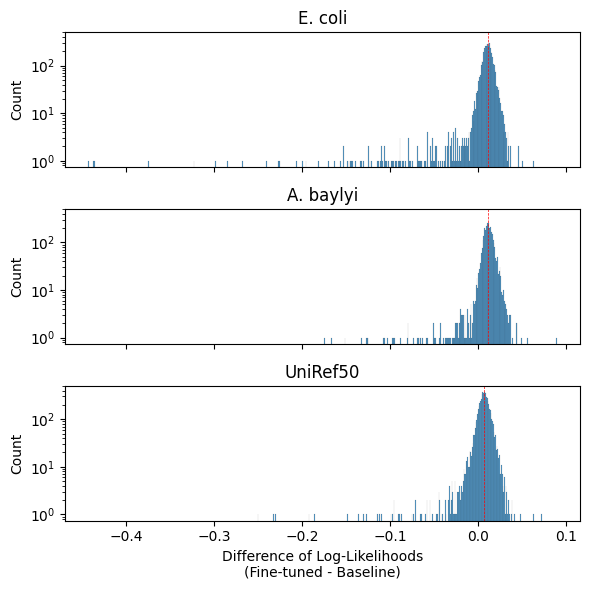

In [ ]:
fig, ax = plt.subplots(3,1, figsize=(6,6), sharex=True, sharey=True)
sns.histplot(loglikelihood_83333_df, x="Difference Log-Likelihood", ax=ax[0])
sns.histplot(loglikelihood_62977_df, x="Difference Log-Likelihood", ax=ax[1])
sns.histplot(loglikelihood_uniref50_df, x="Difference Log-Likelihood", ax=ax[2])

ax[0].axvline(loglikelihood_83333_df["Difference Log-Likelihood"].median(),
            color="red", linestyle="--", linewidth=0.5
)
ax[1].axvline(loglikelihood_62977_df["Difference Log-Likelihood"].median(),
            color="red", linestyle="--", linewidth=0.5
)
ax[2].axvline(loglikelihood_uniref50_df["Difference Log-Likelihood"].median(),
            color="red", linestyle="--", linewidth=0.5
)
ax[0].set_title("E. coli")
ax[1].set_title("A. baylyi")
ax[2].set_title("UniRef50")
ax[2].set_xlabel("Difference of Log-Likelihoods\n(Fine-tuned - Baseline)")
plt.yscale("log")
plt.tight_layout()

When assessing the distribution of differences of log-likelihoods, the differences are not symmetric about the medians, all distributions have long negative tails.

Therefore we cannot use the Wilcoxon Signed-Rank test, as we are in violation of the assumption that the differences must be symmetric about the medians.

The long tail samples will inflate the standard deviation of the difference in log-likelihood, therefore the Cohen's d statistic is not appropriate. Recall d = mean of differences / standard deviation of differences, with an inflated standard deviation, the Cohen's d statistic will be deflated, smaller than expected despite the majority of differences being positive.

In [ ]:
def difference_summary_statistics(difference):
  sign_test_result = binomtest(
      np.sum(difference > 0), len(difference), p=0.5, alternative="two-sided"
  )

  fraction_ci = proportion_confint(
      np.sum(difference > 0), len(difference), alpha=0.05, method="wilson"
  )

  bootstrap_result = bootstrap(
      (difference,), np.median, confidence_level=0.95,
      method="BCa", n_resamples=10000,
  )
  return {
      "Sign Test": {
          "Test Statistic": sign_test_result.statistic,
          "p-value": sign_test_result.pvalue
      },
      "Fraction Improved": {
        "Fraction Improved": np.sum(difference > 0)/len(difference),
        "CI low": fraction_ci[0], "CI high": fraction_ci[1]
      },
      "Bootstrapped Median": {
        "Median": np.median(difference), "CI low": bootstrap_result.confidence_interval.low,
        "CI high": bootstrap_result.confidence_interval.high, "SE": bootstrap_result.standard_error
      }
  }

In [ ]:
difference_summary_83333 = difference_summary_statistics(
    loglikelihood_83333_df["Difference Log-Likelihood"]
)
difference_summary_62977 = difference_summary_statistics(
    loglikelihood_62977_df["Difference Log-Likelihood"]
)
difference_summary_uniref50 = difference_summary_statistics(
    loglikelihood_uniref50_df["Difference Log-Likelihood"]
)

In [ ]:
# Sign Test: Directional significance
pd.DataFrame({
  "A. baylyi": difference_summary_62977["Sign Test"],
  "E. coli": difference_summary_83333["Sign Test"],
  "UniRef50": difference_summary_uniref50["Sign Test"],
}).T

,Test Statistic,p-value
A. baylyi,0.954807,0.0
E. coli,0.929525,0.0
UniRef50,0.860450,0.0


In [ ]:
# Fraction Improved: Frequency of improvement
pd.DataFrame({
  "A. baylyi": difference_summary_62977["Fraction Improved"],
  "E. coli": difference_summary_83333["Fraction Improved"],
  "UniRef50": difference_summary_uniref50["Fraction Improved"],
}).T

,Fraction Improved,CI low,CI high
A. baylyi,0.954807,0.947172,0.961384
E. coli,0.929525,0.921457,0.936821
UniRef50,0.860450,0.851488,0.868954


In [ ]:
# Bootstrapped Median: Magnitude of improvement in terms of log-likelihood
pd.DataFrame({
  "A. baylyi": difference_summary_62977["Bootstrapped Median"],
  "E. coli": difference_summary_83333["Bootstrapped Median"],
  "UniRef50": difference_summary_uniref50["Bootstrapped Median"],
}).T

,Median,CI low,CI high,SE
A. baylyi,0.011366,0.011114,0.011604,0.000131
E. coli,0.010586,0.010403,0.010785,0.000093
UniRef50,0.006714,0.006502,0.006904,0.000098


The fine-tuned model showed **significant positive improvement in the *A. baylyi* proteome**, Sign Test $p_{value} < 0.001$ and improved the log-likelihood 95.4807% (95% CI [94.7172%, 96.1384%]) of sequences, showing consistent performance across the dataset. The median log-likelihood improvement was 0.011366 (95% CI [0.011114, 0.011604]).

The fine-tuned model showed **significant positive improvement** in the *E. coli* proteome, Sign Test $p_{value} < 0.001$ and improved the log-likelihood 92.9525% (95% CI [92.1457%, 93.6821%]) of sequences, showing consistent performance across the dataset but slightly less than *A. baylyi*. The median log-likelihood improvement was 0.010586 (95% CI [0.010403, 0.010785]) less than *A. baylyi*.

The fine-tuned model showed **significant positive improvement** in the UniRef50 sequences, Sign Test $p_{value} < 0.001$ and improved the log-likelihood 86.0% (95% CI [85.1488%, 86.8964%]) of sequences, showing consistent performance across the dataset but least compared to *A. baylyi* and *E. coli*. The median log-likelihood improvement was 0.006714 (95% CI [0.006502, 0.006904]) again the least compared to *A. baylyi* and *E. coli*.

The largest improvement in log-likelihood under the fine-tuned ESM-2 model is  *A. baylyi*, which makes sense as we fine-tuned using the *A. baylyi* proteome followed by *E. coli* then UniRef50. The increased fine-tuned log-likelihood variance for *E. coli* and UniRef50 suggest that the specialization of ESM-2 on *A. baylyi* comes at a cost of being less consistent on the out-of-distribution sequences.

Despite fine-tuning on *A. baylyi*, the median log-likelihood for *E.coli* $-0.402853$ remains greater than *A. baylyi* $-0.403365$.

# Takeaways

This project attempts to fine-tune ESM-2 on the *A. baylyi* proteome to learn species-specific amino acid sequence patterns; complementing the *Species Bias* notebook to improve the likelihood of the *A. baylyi* protein sequences under the ESM-2 model.

To assess the success of the fine-tuning procedure, we define three datasets: the
- *A. baylyi* proteome (in distribution set),
- *E. coli* proteome, and
- subset from UniRef50 (background set).

The baseline and fine-tuned negative log-likelihoods are computed with a single pass over each sequence, summing the conditional probability of every amino acid given the remaining sequence context. The distribution of log-likelihood differences is not normal (normality test $p_{value}$ < 0.001) and asymmetric about the median (long negative tail), violating the assumptions of the paired t-test and Wilcoxon Signed-Rank test respectively. The long negative tail inflates the standard deviation of differences, skewing the Cohen's d statistic. Therefore we used the Sign test for directional significance, fraction improved for relative effect size, and bootstrapped median for absolute magnitude estimation, these metrics are robust to the long negative tail.

The Sign test indicates a positive increase in log-likelihood for *A. baylyi*, *E. coli*, and UniRef50, $p_{value} < 0.001$ for all datasets. The largest fraction of sequences improved was in the *A. baylyi* proteome 95.4807% (95% CI [94.7172%, 96.1384%]), followed by *E. coli* with 92.9525% (95% CI [92.1457%, 93.6821%]), then UniRef50 86.0% (95% CI [85.1488%, 86.8964%]). We expect *A. baylyi* to have the largest improvement given we trained on the proteome, but an increase for the *E. coli*  sequences indicates the model might be picking up on shared protein composition between the *A. baylyi* and *E. coli* proteomes more than the  UniRef50. Similarly, we observe the largest improvement in median log-likelihood in *A. baylyi* 0.011366 (95% CI [0.011114, 0.011604]) > *E. coli* 0.010586 (95% CI [0.010403, 0.010785]) > UniRef50 0.006714 (95% CI [0.006502, 0.006904]), consistent with evolutionary distance to the *A. baylyi* proteome.


### Further Investigations


To improve this analysis, targeting noise during training would be the most impactful. Exploring the hyperparameter space of LoRA with grid search or Bayesian hyperparameter optimization could identify a model that reduces noise and improves convergence.

An alternative approach to targeting training noise could involve incorporating additional proteomes from related species to provide more training data. This could be useful for genes with low sequence similarity with the rest of the proteome. A first step could involve identifying which genes have a decrease in log-likelihood under the fine-tuned model then assess if these proteins correspond to low sequence similarity with the remaining proteome, suggesting additional related species data may improve convergence.

To improve the consistency of the model, we should target the samples at the long negative tails, those sequences with decreased log-likelihood under the fine-tuned model. As noted above, these might be sequences have low sequence similarity to the rest of the *A. baylyi* proteome, or might be test sequences not explicitly seen during training. Applying weighted loss may improve convergence during training and reduce outliers for downstream analysis.

To improve the robustness of fine-tuning and ensure more confidence in validating the adaptation, curating a train-test split that accounts for sequence similarity can be explored. Sequences that share high sequence similarity across training and validation set would artificially inflate the validation performance, therefore tools such as homology-based partitioning can be useful to ensure proper validation. However, these tools will reduce the size of training and validation datasets and exclude data; therefore methods to use the entire proteome while maintaining useful validation strategies should be devised.

### Connection to 01_SpeciesBias


With the previous notebook suggesting proteome composition may drive log-likelihood difference between *E. coli* and *A. baylyi* rather than species-specific bias, we were successful in fine-tuning ESM to improve *A. baylyi* log-likelihoods. The fine-tuned model improves the *A. baylyi* log-likelihoods in 95.4807% of sequences, it would be interesting to assess species-specific bias in the fine-tuned model following the framework of the first notebook, given that we also see an increase in *E. coli* log-likelihoods in 92.9525% of the proteome.